# DM1 09d — Clustering interpretation, robustness, and final reporting
# DM1 09d — 聚类解释、稳健性与报告定稿

This notebook does not re-select or retrain the clustering model. It uses the completed `all-MiniLM-L6-v2 + KMeans (k=12)` results from Notebook 09c to:

1. organize the 12 empirical subtopics into reportable macro themes;
2. replace overlapping high-frequency terms with more distinctive keywords;
3. separate core, intermediate, and low-confidence comments using semantic membership strength;
4. combine manual-review evidence, community concentration, baseline agreement, and representative examples; and
5. export topic tables, figures, and conclusion text that can be used directly in the report.

Mixed and residual clusters are retained rather than forcing borderline comments into artificially clean topics.

本 notebook 不重新选择或训练聚类模型。它使用 09c 已完成的 `all-MiniLM-L6-v2 + KMeans (k=12)` 结果，完成以下工作：

1. 将 12 个经验子主题组织为可报告的宏观主题体系；
2. 用区分性关键词代替容易重叠的原始高频词；
3. 根据语义成员强度区分核心、一般与低置信度评论；
4. 汇总人工复核、社区偏斜、基线一致性和代表性案例；
5. 输出可以直接用于报告结尾的主题表、图和结论文本。

这里保留混合类和残余类，避免为了“主题都很漂亮”而强行重新分配边界评论。

In [1]:
# Load libraries and define paths. / 导入依赖并设置路径。
from pathlib import Path
import json
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path(r"D:\DM1_project")
INPUT_DIR = ROOT / "v2_clustering_outputs_09c_review_informed"
REVIEW_DIR = ROOT / "outputs" / "review_09c_astra_20261003"
OUTPUT_DIR = ROOT / "v2_clustering_outputs_09d_interpretation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ASSIGNMENT_PATH = INPUT_DIR / "v2_controlled_cluster_assignments.parquet"
RANDOM_REVIEW_PATH = REVIEW_DIR / "09c_semantic_random_review_60.csv"

print("Input / 输入:", ASSIGNMENT_PATH)
print("Output / 输出:", OUTPUT_DIR)

Input / 输入: D:\DM1_project\v2_clustering_outputs_09c_review_informed\v2_controlled_cluster_assignments.parquet
Output / 输出: D:\DM1_project\v2_clustering_outputs_09d_interpretation


## 1. Load and validate the 09c results / 读取并验证 09c 结果

Notebook 09c uses an equal sample from six communities: 4,705 comments per community and 28,230 comments in total. This prevents larger communities from dominating the topic centroids. Consequently, the topic shares below describe the balanced modeling sample rather than the natural pooled prevalence across all six communities.

09c 的训练样本按六个社区等量抽取，每个社区 4,705 条，共 28,230 条。这个设计防止大社区主导主题中心，也意味着当前主题比例描述的是平衡样本，而不是六个社区合并后的自然总体占比。

In [2]:
# Load 09c outputs and verify the balanced modeling sample. / 读取 09c 输出并验证平衡建模样本。
df = pd.read_parquet(ASSIGNMENT_PATH)
quality_09c = pd.read_csv(INPUT_DIR / "semantic_cluster_quality.csv")
subreddit_pct_09c = pd.read_csv(INPUT_DIR / "advanced_subreddit_topic_percentages.csv")
semantic_stability = pd.read_csv(INPUT_DIR / "semantic_stability.csv")
baseline_stability = pd.read_csv(INPUT_DIR / "baseline_stability.csv")
subcluster_diag = pd.read_csv(INPUT_DIR / "semantic_subcluster_diagnostics.csv")

assert len(df) == 28_230
assert set(df["advanced_cluster"].unique()) == set(range(12))
assert df.groupby("subreddit").size().nunique() == 1

print(f"Rows / 行数: {len(df):,}")
print(df.groupby("subreddit").size().to_string())
print(f"Semantic seed mean ARI / 语义模型平均种子 ARI: {semantic_stability.ARI.mean():.4f}")
print(f"Baseline seed mean ARI / 基线模型平均种子 ARI: {baseline_stability.ARI.mean():.4f}")

Rows / 行数: 28,230
subreddit
Futurology       4705
changemyview     4705
climate          4705
climatechange    4705
conspiracy       4705
energy           4705
Semantic seed mean ARI / 语义模型平均种子 ARI: 0.9753
Baseline seed mean ARI / 基线模型平均种子 ARI: 0.8161


## 2. Define the reporting taxonomy / 固定报告用层级主题体系

`advanced_cluster` remains the original model output. `subtopic_name` is the interpretation assigned after review, while `macro_theme` is the higher-level reporting category. Neither field changes the original cluster number of any comment.

`advanced_cluster` 保留为模型原始输出。`subtopic_name` 是人工复核后的解释名称，`macro_theme` 是报告层面的汇总。二者不会改变任何评论的原始聚类编号。

In [3]:
# Define the reviewed bilingual taxonomy. / 定义人工复核后的双语主题体系。
taxonomy_rows = [
    (0, "气候观测、变暖证据与气候科学", "Climate observations and science", "气候科学与物理影响", "Climate science and physical impacts", "clear", "可作为独立主题解释", "Suitable for interpretation as a standalone topic"),
    (1, "电动车与清洁交通", "Electric vehicles and clean transport", "能源技术与基础设施", "Energy technologies and infrastructure", "clear_with_noise", "少量泛科技或汽车市场内容", "Contains a small amount of general technology or automobile-market content"),
    (2, "气候信念、否认与公共传播", "Climate belief, denial, and communication", "公众认知与未来叙事", "Public understanding and future narratives", "broad", "范围较宽，重点是信念与传播", "Broad scope centered on belief and communication"),
    (3, "可再生能源、电网与储能", "Renewables, grids, and storage", "能源技术与基础设施", "Energy technologies and infrastructure", "clear_with_noise", "少量一般能源词义噪声", "Contains a small amount of generic-energy lexical noise"),
    (4, "排放削减与减缓行动", "Emission reduction and mitigation action", "减缓行动与碳管理", "Mitigation action and carbon management", "broad", "涵盖个人、政策与社会减缓行动", "Covers individual, policy, and societal mitigation action"),
    (5, "未来风险、崩溃叙事与人类后果", "Future risk, collapse, and human consequences", "公众认知与未来叙事", "Public understanding and future narratives", "broad", "涵盖风险、未来和社会后果", "Covers risk, the future, and societal consequences"),
    (6, "中国与全球能源转型", "China and the global energy transition", "转型政治经济与地缘结构", "Transition political economy and geopolitics", "clear", "中国、制造能力和全球责任", "China, manufacturing capacity, and global responsibility"),
    (7, "温室气体、碳循环与碳移除", "Greenhouse gases, carbon cycle, and removal", "减缓行动与碳管理", "Mitigation action and carbon management", "clear", "CO2、甲烷、碳捕集与自然碳汇", "CO2, methane, carbon capture, and natural carbon sinks"),
    (8, "核能与核聚变", "Nuclear energy and fusion", "能源技术与基础设施", "Energy technologies and infrastructure", "clear", "核裂变、核聚变及其成本风险", "Nuclear fission, fusion, and their costs and risks"),
    (9, "化石燃料及转型政治经济", "Fossil fuels and transition political economy", "转型政治经济与地缘结构", "Transition political economy and geopolitics", "clear", "石油、天然气、煤炭和产业转型", "Oil, natural gas, coal, and industrial transition"),
    (10, "天气、气候影响与适应", "Weather, climate impacts, and adaptation", "气候科学与物理影响", "Climate science and physical impacts", "mixed", "混入热泵和建筑能源内容，需保守解释", "Includes heat-pump and building-energy content; interpret cautiously"),
    (11, "综合政策与公众争论", "Cross-cutting policy and public debate", "跨主题综合残余", "Cross-cutting residual", "residual", "低分离度残余类，不作为单一实质主题", "Low-separation residual cluster; do not interpret as one substantive topic"),
]

taxonomy = pd.DataFrame(
    taxonomy_rows,
    columns=[
        "advanced_cluster", "subtopic_name", "subtopic_name_en",
        "macro_theme", "macro_theme_en", "interpretation_status",
        "interpretation_note", "interpretation_note_en",
    ],
)

df = df.merge(taxonomy, on="advanced_cluster", how="left", validate="many_to_one")
assert df["subtopic_name"].notna().all()
taxonomy

,advanced_cluster,subtopic_name,subtopic_name_en,macro_theme,macro_theme_en,interpretation_status,interpretation_note,interpretation_note_en
0,0,气候观测、变暖证据与气候科学,Climate observations and science,气候科学与物理影响,Climate science and physical impacts,clear,可作为独立主题解释,Suitable for interpretation as a standalone topic
1,1,电动车与清洁交通,Electric vehicles and clean transport,能源技术与基础设施,Energy technologies and infrastructure,clear_with_noise,少量泛科技或汽车市场内容,Contains a small amount of general technology ...
2,2,气候信念、否认与公共传播,"Climate belief, denial, and communication",公众认知与未来叙事,Public understanding and future narratives,broad,范围较宽，重点是信念与传播,Broad scope centered on belief and communication
3,3,可再生能源、电网与储能,"Renewables, grids, and storage",能源技术与基础设施,Energy technologies and infrastructure,clear_with_noise,少量一般能源词义噪声,Contains a small amount of generic-energy lexi...
4,4,排放削减与减缓行动,Emission reduction and mitigation action,减缓行动与碳管理,Mitigation action and carbon management,broad,涵盖个人、政策与社会减缓行动,"Covers individual, policy, and societal mitiga..."
5,5,未来风险、崩溃叙事与人类后果,"Future risk, collapse, and human consequences",公众认知与未来叙事,Public understanding and future narratives,broad,涵盖风险、未来和社会后果,"Covers risk, the future, and societal conseque..."
6,6,中国与全球能源转型,China and the global energy transition,转型政治经济与地缘结构,Transition political economy and geopolitics,clear,中国、制造能力和全球责任,"China, manufacturing capacity, and global resp..."
7,7,温室气体、碳循环与碳移除,"Greenhouse gases, carbon cycle, and removal",减缓行动与碳管理,Mitigation action and carbon management,clear,CO2、甲烷、碳捕集与自然碳汇,"CO2, methane, carbon capture, and natural carb..."
8,8,核能与核聚变,Nuclear energy and fusion,能源技术与基础设施,Energy technologies and infrastructure,clear,核裂变、核聚变及其成本风险,"Nuclear fission, fusion, and their costs and r..."
9,9,化石燃料及转型政治经济,Fossil fuels and transition political economy,转型政治经济与地缘结构,Transition political economy and geopolitics,clear,石油、天然气、煤炭和产业转型,"Oil, natural gas, coal, and industrial transition"


## 3. Separate cluster assignment from interpretation confidence / 将“聚类归属”与“解释置信度”分开

Membership strength is the cosine similarity between a comment vector and its assigned topic centroid. Common thresholds are used so that ambiguity can be compared across topics:

- `high`: ≥ 0.60, suitable for topic descriptions and representative examples;
- `medium`: 0.45–0.60, retained in topic shares but interpreted cautiously;
- `low`: < 0.45, treated as a boundary case in sensitivity analysis.

The bottom 10% within each cluster is also flagged so that a globally weak cluster is not hidden by a common threshold.

成员强度是评论向量与所属主题中心的余弦相似度。这里使用统一阈值，使不同主题的模糊程度可以比较：

- `high`：≥ 0.60，适合用于主题描述和代表案例；
- `medium`：0.45–0.60，可以计入主题比例，但解释要保守；
- `low`：< 0.45，作为边界评论，用于敏感性分析。

此外再标记每个主题内部最低 10% 的评论，防止某些整体较弱的主题被统一阈值掩盖。

In [4]:
# Convert centroid similarity into comparable confidence bands.
# 将主题中心相似度转换为可比较的置信度等级。
df["confidence_band"] = pd.cut(
    df["advanced_membership_strength"],
    bins=[-np.inf, 0.45, 0.60, np.inf],
    labels=["low", "medium", "high"],
    right=False,
)

p10_by_cluster = df.groupby("advanced_cluster")["advanced_membership_strength"].quantile(0.10)
df["within_cluster_bottom_10pct"] = (
    df["advanced_membership_strength"]
    < df["advanced_cluster"].map(p10_by_cluster)
)

confidence_pct = (
    pd.crosstab(df["advanced_cluster"], df["confidence_band"], normalize="index")
    .mul(100)
    .reindex(columns=["high", "medium", "low"], fill_value=0)
    .reset_index()
)
confidence_pct.columns = ["advanced_cluster", "high_conf_pct", "medium_conf_pct", "low_conf_pct"]
confidence_pct.round(1)

,advanced_cluster,high_conf_pct,medium_conf_pct,low_conf_pct
0,0,75.5,21.4,3.1
1,1,69.3,25.1,5.6
2,2,86.6,13.2,0.2
3,3,66.8,27.2,6.0
4,4,71.9,25.5,2.6
5,5,81.7,17.4,0.9
6,6,93.5,6.4,0.1
7,7,68.5,25.3,6.1
8,8,77.6,19.1,3.3
9,9,66.3,30.4,3.3


## 4. Re-extract distinctive keywords / 重新提取区分性关键词

Ordinary TF-IDF allows corpus-wide terms such as `climate`, `change`, `people`, and `think` to dominate many topics. Here, common corpus terms are removed before class-based TF-IDF is used to identify terms that distinguish each topic from the others.

普通 TF-IDF 容易让 `climate`, `change`, `people`, `think` 等全局高频词占据所有主题。这里先移除研究语料中的通用词，再使用 class-based TF-IDF，从“该主题相对于其他主题更有区分度”的角度提取词语。

In [5]:
# Remove corpus-wide conversational terms before class-based TF-IDF.
# 在计算 class-based TF-IDF 前移除语料中的通用对话词。
domain_stop = {
    "climate", "change", "climatechange", "global", "people", "person", "just", "like",
    "don", "doesn", "didn", "isn", "aren", "think", "really", "thing", "things", "way",
    "know", "make", "makes", "want", "need", "time", "times", "year", "years", "world",
    "say", "says", "said", "ve", "re", "ll", "im", "reddit", "https", "http", "com", "amp",
    "would", "could", "also", "much", "many", "get", "got", "going", "one", "even"
}
stop_words = sorted(set(ENGLISH_STOP_WORDS).union(domain_stop))

vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=8,
    max_df=0.85,
    max_features=40_000,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9\-]{1,}\b",
)
X = vectorizer.fit_transform(df["clean_text"].fillna(""))
terms = np.asarray(vectorizer.get_feature_names_out())

cluster_counts = np.vstack([
    np.asarray(X[df["advanced_cluster"].to_numpy() == c].sum(axis=0)).ravel()
    for c in range(12)
])
class_lengths = cluster_counts.sum(axis=1, keepdims=True)
class_tf = cluster_counts / np.maximum(class_lengths, 1)
global_term_count = cluster_counts.sum(axis=0)
idf = np.log1p(class_lengths.mean() / np.maximum(global_term_count, 1))
ctfidf = class_tf * idf

term_rows = []
for c in range(12):
    order = np.argsort(ctfidf[c])[::-1]
    chosen = []
    for idx in order:
        term = terms[idx]
        # Avoid duplicate top terms caused by singular/plural or substring overlap.
        # 避免单复数或包含关系造成前十名重复。
        if any(term == old or term in old or old in term for old in chosen):
            continue
        chosen.append(term)
        term_rows.append({
            "advanced_cluster": c,
            "rank": len(chosen),
            "term": term,
            "ctfidf_score": float(ctfidf[c, idx]),
        })
        if len(chosen) == 12:
            break

distinctive_terms = pd.DataFrame(term_rows)
distinctive_wide = (
    distinctive_terms.groupby("advanced_cluster")["term"]
    .apply(lambda x: ", ".join(x))
    .rename("distinctive_terms")
    .reset_index()
)
distinctive_wide.merge(
    taxonomy[["advanced_cluster", "subtopic_name", "subtopic_name_en"]],
    on="advanced_cluster",
)

,advanced_cluster,distinctive_terms,subtopic_name,subtopic_name_en
0,0,"warming, temperature, ice, data, earth, co2, s...",气候观测、变暖证据与气候科学,Climate observations and science
1,1,"ev, car, electric, battery, vehicles, ice, bat...",电动车与清洁交通,Electric vehicles and clean transport
2,2,"science, real, warming, believe, scientists, a...",气候信念、否认与公共传播,"Climate belief, denial, and communication"
3,3,"solar, energy, power, wind, grid, electricity,...",可再生能源、电网与储能,"Renewables, grids, and storage"
4,4,"emissions, carbon, meat, energy, food, use, fo...",排放削减与减缓行动,Emission reduction and mitigation action
5,5,"planet, humans, life, earth, humanity, populat...",未来风险、崩溃叙事与人类后果,"Future risk, collapse, and human consequences"
6,6,"china, coal, emissions, energy, chinese, solar...",中国与全球能源转型,China and the global energy transition
7,7,"co2, carbon, atmosphere, methane, capture, emi...",温室气体、碳循环与碳移除,"Greenhouse gases, carbon cycle, and removal"
8,8,"nuclear, power, fusion, energy, reactors, plan...",核能与核聚变,Nuclear energy and fusion
9,9,"oil, fossil, energy, gas, fuels, companies, co...",化石燃料及转型政治经济,Fossil fuels and transition political economy


## 5. Integrate review evidence / 合并人工复核证据

Five comments are sampled randomly from each semantic cluster for a reading-based check independent of centroid examples. `fit` means that the comment matches the topic, `partial` means that it matches only part of the topic, and `mismatch` indicates a misassignment. Because the review sample is small, it is used to identify obvious problems rather than to estimate a precise population error rate.

每个语义簇随机抽取 5 条进行独立于中心案例的阅读复核。`fit` 表示评论与主题一致，`partial` 表示只匹配一部分，`mismatch` 表示错配。样本量较小，因此它用于发现明显问题，不作为精确总体误差率。

In [6]:
# Summarize five random review cases per semantic cluster.
# 汇总每个语义簇的 5 条随机复核案例。
review = pd.read_csv(RANDOM_REVIEW_PATH)
review["fit_weight"] = review["cluster_fit_review"].map({"fit": 1.0, "partial": 0.5, "mismatch": 0.0})
review_summary = (
    review.groupby("cluster")
    .agg(
        reviewed_n=("comment_id", "size"),
        reviewed_substantive=("substantive_for_climate_or_transition", "sum"),
        review_fit_score=("fit_weight", "mean"),
        reviewed_mismatch=("cluster_fit_review", lambda x: int((x == "mismatch").sum())),
    )
    .reset_index()
    .rename(columns={"cluster": "advanced_cluster"})
)
review_summary["review_fit_score"] *= 100
review_summary

,advanced_cluster,reviewed_n,reviewed_substantive,review_fit_score,reviewed_mismatch
0,0,5,5,100.0,0
1,1,5,4,60.0,1
2,2,5,4,80.0,1
3,3,5,4,80.0,1
4,4,5,5,100.0,0
5,5,5,5,100.0,0
6,6,5,5,100.0,0
7,7,5,5,100.0,0
8,8,5,5,100.0,0
9,9,5,5,100.0,0


## 6. Build the final topic profiles / 形成最终主题画像

Each topic profile combines cluster size, membership confidence, review evidence, and community concentration. Topic names are supported by this evidence jointly rather than by keywords alone.

主题画像同时呈现规模、置信度、人工复核和社区集中度。主题名称不能只由关键词决定，而要由这些证据共同支持。

In [7]:
# Combine size, confidence, review, source, and keyword evidence.
# 合并规模、置信度、人工复核、来源和关键词证据。
cluster_base = (
    df.groupby("advanced_cluster")
    .agg(
        size=("comment_id", "size"),
        mean_membership=("advanced_membership_strength", "mean"),
        median_membership=("advanced_membership_strength", "median"),
        mean_review_gate_score=("review_gate_score", "mean"),
        direct_comment_share=("direct_comment", "mean"),
    )
    .reset_index()
)
cluster_base["sample_share_pct"] = cluster_base["size"] / len(df) * 100

source_share = (
    df.groupby(["advanced_cluster", "subreddit"]).size()
    .rename("n").reset_index()
)
source_share["share"] = source_share["n"] / source_share.groupby("advanced_cluster")["n"].transform("sum")
largest_source = source_share.loc[source_share.groupby("advanced_cluster")["share"].idxmax()]
largest_source = largest_source[["advanced_cluster", "subreddit", "share"]].rename(
    columns={"subreddit": "largest_subreddit", "share": "largest_subreddit_share"}
)

profiles = (
    taxonomy
    .merge(cluster_base, on="advanced_cluster")
    .merge(confidence_pct, on="advanced_cluster")
    .merge(review_summary, on="advanced_cluster")
    .merge(largest_source, on="advanced_cluster")
    .merge(distinctive_wide, on="advanced_cluster")
)

profiles["reporting_treatment"] = profiles["interpretation_status"].map({
    "clear": "独立报告",
    "clear_with_noise": "独立报告并注明少量噪声",
    "broad": "保留主题并使用宽泛名称",
    "mixed": "作为混合主题保守报告",
    "residual": "作为其他/残余类报告，不作单一议题推断",
})
profiles["reporting_treatment_en"] = profiles["interpretation_status"].map({
    "clear": "Report as a standalone topic",
    "clear_with_noise": "Report as a standalone topic with a minor-noise caveat",
    "broad": "Retain with a deliberately broad label",
    "mixed": "Report conservatively as a mixed topic",
    "residual": "Report as other/residual; do not infer one substantive issue",
})

best_local = subcluster_diag.loc[
    subcluster_diag.groupby("parent_cluster")["local_silhouette_cosine"].idxmax(),
    ["parent_cluster", "local_k", "local_silhouette_cosine"]
].rename(columns={
    "parent_cluster": "advanced_cluster",
    "local_k": "best_local_k",
    "local_silhouette_cosine": "best_local_silhouette",
})
split_decisions = {
    2: "不拆分：局部结构弱，保留宽泛主题",
    3: "不拆分：现有主题清晰，局部增益不足",
    9: "暂不拆分：虽是最高候选，但不足以支持稳定子主题",
    10: "不拆分：保留混合标签比强行切分更诚实",
    11: "不拆分：残余讨论呈连续分布，没有稳定子结构",
}
best_local["split_decision"] = best_local["advanced_cluster"].map(split_decisions)
split_decisions_en = {
    2: "Do not split: weak local structure; retain the broad topic",
    3: "Do not split: the current topic is clear and the local gain is insufficient",
    9: "Do not split yet: the strongest candidate is still insufficient for stable subtopics",
    10: "Do not split: retaining a mixed label is more defensible than forcing a division",
    11: "Do not split: residual discussion is continuous and has no stable substructure",
}
best_local["split_decision_en"] = best_local["advanced_cluster"].map(split_decisions_en)
profiles = profiles.merge(best_local, on="advanced_cluster", how="left")

display_cols = [
    "advanced_cluster", "subtopic_name", "subtopic_name_en", "macro_theme", "macro_theme_en",
    "size", "sample_share_pct",
    "mean_membership", "high_conf_pct", "low_conf_pct", "review_fit_score",
    "interpretation_status", "reporting_treatment", "reporting_treatment_en", "distinctive_terms"
]
profiles[display_cols].round(2)

,advanced_cluster,subtopic_name,subtopic_name_en,macro_theme,macro_theme_en,size,sample_share_pct,mean_membership,high_conf_pct,low_conf_pct,review_fit_score,interpretation_status,reporting_treatment,reporting_treatment_en,distinctive_terms
0,0,气候观测、变暖证据与气候科学,Climate observations and science,气候科学与物理影响,Climate science and physical impacts,2279,8.07,0.66,75.52,3.07,100.0,clear,独立报告,Report as a standalone topic,"warming, temperature, ice, data, earth, co2, s..."
1,1,电动车与清洁交通,Electric vehicles and clean transport,能源技术与基础设施,Energy technologies and infrastructure,1714,6.07,0.65,69.31,5.60,60.0,clear_with_noise,独立报告并注明少量噪声,Report as a standalone topic with a minor-nois...,"ev, car, electric, battery, vehicles, ice, bat..."
2,2,气候信念、否认与公共传播,"Climate belief, denial, and communication",公众认知与未来叙事,Public understanding and future narratives,3570,12.65,0.69,86.55,0.20,80.0,broad,保留主题并使用宽泛名称,Retain with a deliberately broad label,"science, real, warming, believe, scientists, a..."
3,3,可再生能源、电网与储能,"Renewables, grids, and storage",能源技术与基础设施,Energy technologies and infrastructure,3436,12.17,0.64,66.82,6.02,80.0,clear_with_noise,独立报告并注明少量噪声,Report as a standalone topic with a minor-nois...,"solar, energy, power, wind, grid, electricity,..."
4,4,排放削减与减缓行动,Emission reduction and mitigation action,减缓行动与碳管理,Mitigation action and carbon management,2983,10.57,0.65,71.87,2.65,100.0,broad,保留主题并使用宽泛名称,Retain with a deliberately broad label,"emissions, carbon, meat, energy, food, use, fo..."
5,5,未来风险、崩溃叙事与人类后果,"Future risk, collapse, and human consequences",公众认知与未来叙事,Public understanding and future narratives,2672,9.47,0.68,81.70,0.90,100.0,broad,保留主题并使用宽泛名称,Retain with a deliberately broad label,"planet, humans, life, earth, humanity, populat..."
6,6,中国与全球能源转型,China and the global energy transition,转型政治经济与地缘结构,Transition political economy and geopolitics,1148,4.07,0.73,93.47,0.09,100.0,clear,独立报告,Report as a standalone topic,"china, coal, emissions, energy, chinese, solar..."
7,7,温室气体、碳循环与碳移除,"Greenhouse gases, carbon cycle, and removal",减缓行动与碳管理,Mitigation action and carbon management,2038,7.22,0.64,68.55,6.13,100.0,clear,独立报告,Report as a standalone topic,"co2, carbon, atmosphere, methane, capture, emi..."
8,8,核能与核聚变,Nuclear energy and fusion,能源技术与基础设施,Energy technologies and infrastructure,1324,4.69,0.67,77.57,3.32,100.0,clear,独立报告,Report as a standalone topic,"nuclear, power, fusion, energy, reactors, plan..."
9,9,化石燃料及转型政治经济,Fossil fuels and transition political economy,转型政治经济与地缘结构,Transition political economy and geopolitics,2856,10.12,0.63,66.28,3.29,100.0,clear,独立报告,Report as a standalone topic,"oil, fossil, energy, gas, fuels, companies, co..."


## 7. Select representative examples for reporting / 选择报告用代表案例

Representative examples are selected from comments with high membership strength, with no more than one example from the same post. They illustrate the meaning of a topic; they do not establish its prevalence.

代表案例来自每个主题中成员强度较高的评论，并限制同一帖子最多出现一次。它们用于说明主题含义，不用于证明主题比例。

In [8]:
# Select high-confidence examples while limiting each post to one example.
# 选择高置信度案例，并限制每个帖子最多贡献一条。
example_rows = []
for c in range(12):
    part = df[df["advanced_cluster"] == c].copy()
    part = part[(part["confidence_band"] == "high") & (part["review_gate_score"] >= 0.655)]
    part = part.sort_values(["advanced_membership_strength", "review_gate_score"], ascending=False)
    part = part.drop_duplicates("post_id").head(3)
    for rank, (_, row) in enumerate(part.iterrows(), start=1):
        text = " ".join(str(row["clean_text"]).split())
        title = " ".join(str(row["post_title"]).split())
        example_rows.append({
            "advanced_cluster": c,
            "rank": rank,
            "comment_id": row["comment_id"],
            "subreddit": row["subreddit"],
            "post_title": title,
            "comment_excerpt": text[:500],
            "membership_strength": row["advanced_membership_strength"],
            "review_gate_score": row["review_gate_score"],
        })

examples = pd.DataFrame(example_rows).merge(
    taxonomy[["advanced_cluster", "subtopic_name", "subtopic_name_en", "macro_theme", "macro_theme_en"]],
    on="advanced_cluster",
    how="left",
)
examples.head(12)

,advanced_cluster,rank,comment_id,subreddit,post_title,comment_excerpt,membership_strength,review_gate_score,subtopic_name,subtopic_name_en,macro_theme,macro_theme_en
0,0,1,khuqdyi,climatechange,"Please, we need to be united. If you believe c...","> Which is false, and is the reason why you ca...",0.860126,0.660532,气候观测、变暖证据与气候科学,Climate observations and science,气候科学与物理影响,Climate science and physical impacts
1,0,2,m0r2ql8,conspiracy,Climate Change Hoax,I'd actually debate that using a lifetime as a...,0.852365,0.774719,气候观测、变暖证据与气候科学,Climate observations and science,气候科学与物理影响,Climate science and physical impacts
2,0,3,kh88zm1,climate,Efforts to keep global heating to 1.5C will ef...,This subreddit is full of r/collapse mooks who...,0.841637,0.707119,气候观测、变暖证据与气候科学,Climate observations and science,气候科学与物理影响,Climate science and physical impacts
3,1,1,nvc5rj0,changemyview,CMV: Electric cars are just not the future wit...,What do you think the future is and how could ...,0.869879,0.728255,电动车与清洁交通,Electric vehicles and clean transport,能源技术与基础设施,Energy technologies and infrastructure
4,1,2,mstbvv0,changemyview,CMV: Gas prices in the Southwest and PNW are l...,We don’t have a better alternative yet. EV sti...,0.864527,0.750551,电动车与清洁交通,Electric vehicles and clean transport,能源技术与基础设施,Energy technologies and infrastructure
5,1,3,nr0omyo,changemyview,CMV: EVs are actually good.,EV's are great until you factor in the environ...,0.863581,0.735601,电动车与清洁交通,Electric vehicles and clean transport,能源技术与基础设施,Energy technologies and infrastructure
6,2,1,kcp3tfc,climatechange,The climate change we caused is here for at le...,WE have no control of the climate. Period. It’...,0.864520,0.808118,气候信念、否认与公共传播,"Climate belief, denial, and communication",公众认知与未来叙事,Public understanding and future narratives
7,2,2,lkj9ade,conspiracy,Nothing says stop climate change like owning a...,These climate change posts on this subreddit a...,0.859452,0.718502,气候信念、否认与公共传播,"Climate belief, denial, and communication",公众认知与未来叙事,Public understanding and future narratives
8,2,3,ntodv08,conspiracy,Where did all the climate change go?,It's an inconvenient truth that climate change...,0.851456,0.700915,气候信念、否认与公共传播,"Climate belief, denial, and communication",公众认知与未来叙事,Public understanding and future narratives
9,3,1,mt937rf,changemyview,CMV: Electric vehicles (EVs) are overall good ...,The section right before talks about electrifi...,0.867378,0.799436,可再生能源、电网与储能,"Renewables, grids, and storage",能源技术与基础设施,Energy technologies and infrastructure


## 8. Community structure and baseline sensitivity / 社区结构和基线敏感性

Community percentages are calculated within each subreddit. Because every community contributes the same number of comments, we can compare which topics are discussed more often in different communities. The pooled sample proportions must not be interpreted as the natural prevalence of topics across Reddit.

The lexical baseline and semantic model measure different forms of similarity. ARI and NMI are used to assess how strongly the result depends on the representation space, not to require identical labels from both models.

社区百分比按各社区内部计算。由于每个社区样本量相同，可以比较不同社区更常讨论哪些主题，但不能把六个社区合并后的样本比例解释为 Reddit 总体比例。

基线与语义模型衡量不同的相似性。ARI/NMI 用于确认结论是否完全依赖某一种空间，而不是要求两套标签完全一致。

In [9]:
# Compare within-community topic shares and lexical/semantic agreement.
# 比较社区内部主题占比以及词汇/语义模型的一致性。
community_counts = pd.crosstab(df["subreddit"], df["advanced_cluster"])
community_pct = community_counts.div(community_counts.sum(axis=1), axis=0) * 100

agreement = {
    "n": int(len(df)),
    "adjusted_rand_index": float(adjusted_rand_score(df["baseline_cluster"], df["advanced_cluster"])),
    "adjusted_mutual_information": float(adjusted_mutual_info_score(df["baseline_cluster"], df["advanced_cluster"])),
    "normalized_mutual_information": float(normalized_mutual_info_score(df["baseline_cluster"], df["advanced_cluster"])),
    "semantic_seed_mean_ari": float(semantic_stability.ARI.mean()),
    "baseline_seed_mean_ari": float(baseline_stability.ARI.mean()),
}
print("Baseline–semantic agreement / 基线与语义模型一致性:")
print(json.dumps(agreement, indent=2))
community_pct.round(1)

Baseline–semantic agreement / 基线与语义模型一致性:
{
  "n": 28230,
  "adjusted_rand_index": 0.2145420772343157,
  "adjusted_mutual_information": 0.33833424815625174,
  "normalized_mutual_information": 0.3389287953105133,
  "semantic_seed_mean_ari": 0.9752968943404081,
  "baseline_seed_mean_ari": 0.8161019985986068
}


advanced_cluster,0,1,2,3,4,5,6,7,8,9,10,11
subreddit,,,,,,,,,,,,
Futurology,3.9,9.2,4.7,21.9,8.3,11.1,6.7,6.5,10.6,7.7,4.4,5.0
changemyview,2.6,8.2,10.4,6.5,18.4,17.7,2.8,3.0,8.1,3.9,3.3,15.1
climate,7.5,2.1,20.3,4.0,14.7,10.9,2.9,7.1,2.6,10.1,8.0,9.8
climatechange,16.3,2.5,14.6,6.4,10.5,11.2,2.3,12.4,3.4,4.7,12.5,3.4
conspiracy,17.2,2.4,23.3,2.6,6.8,5.0,1.2,10.1,2.2,7.9,11.2,10.1
energy,1.0,12.1,2.7,31.7,4.7,0.9,8.7,4.1,1.2,26.3,1.6,5.2


## 9. Visual checks / 图形化检查

The first figure shows the high-, medium-, and low-confidence composition of each topic. The second figure shows topic shares within each community. The report should use named topics rather than bare cluster numbers whenever possible.

第一张图同时展示主题的高/中/低置信度构成；第二张图展示社区内部主题比例。报告正文应优先使用有名称的主题，而不是裸露的簇编号。

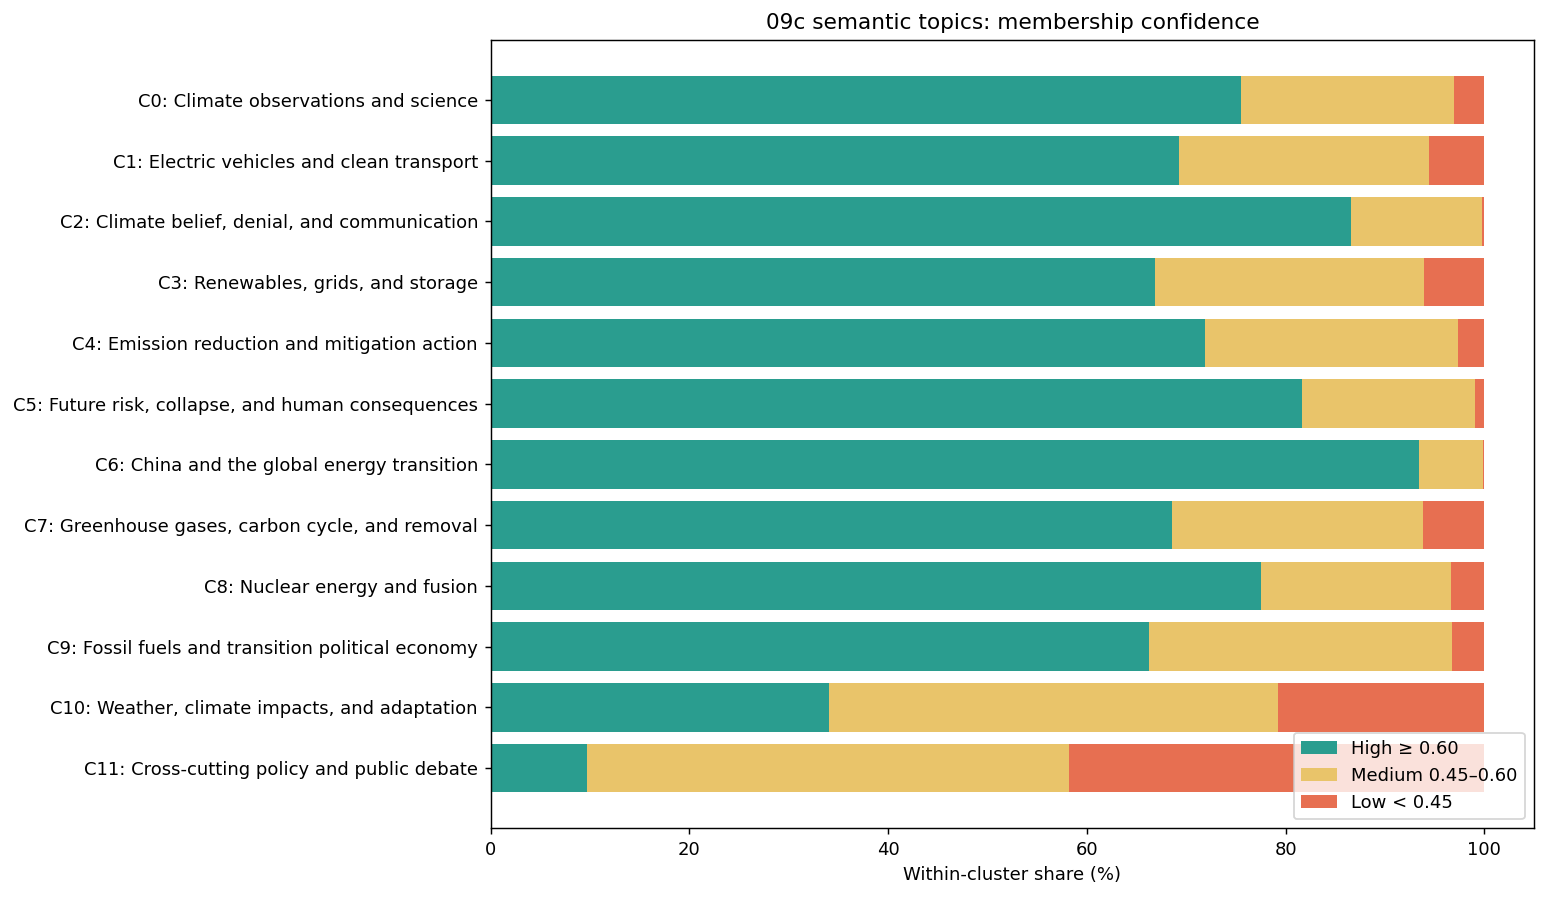

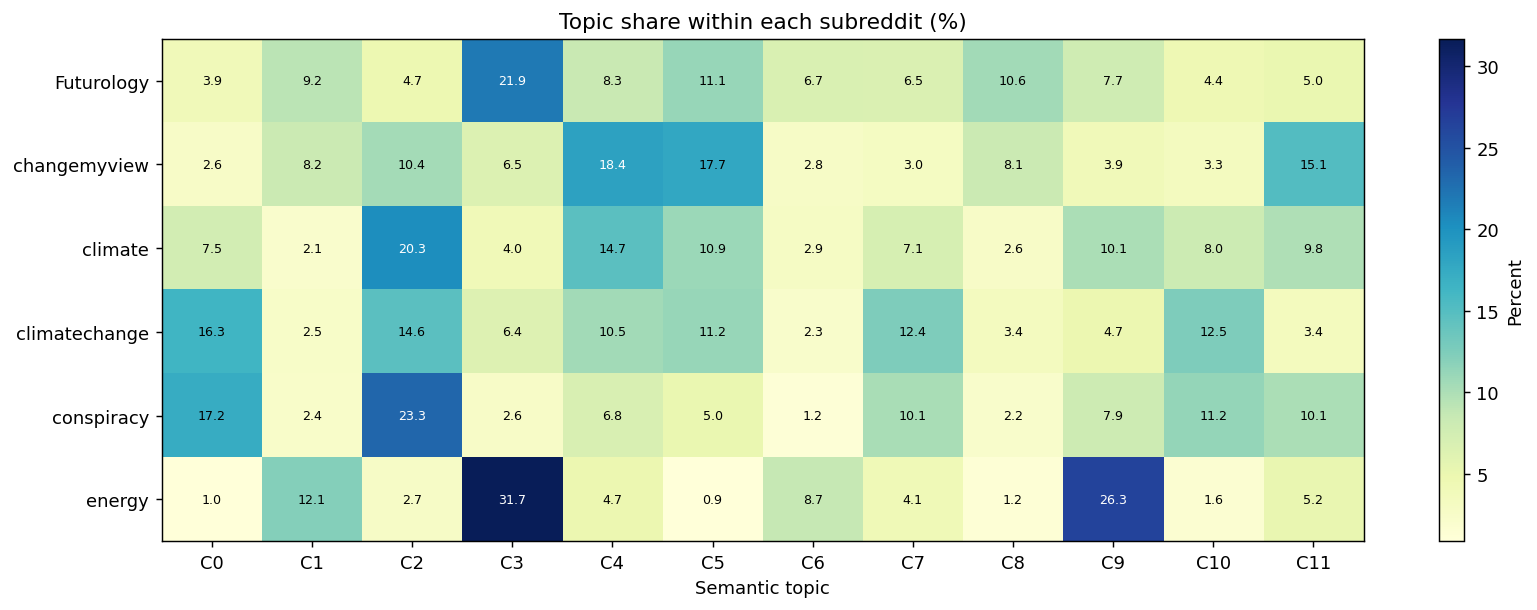

In [10]:
# Create bilingual figures for confidence and community structure.
# 绘制主题置信度和社区结构的双语图表。
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 12, "axes.labelsize": 10})

plot_df = profiles.sort_values("advanced_cluster").copy()
labels = [f"C{r.advanced_cluster}: {r.subtopic_name_en}" for r in plot_df.itertuples()]

fig, ax = plt.subplots(figsize=(12, 7))
left = np.zeros(len(plot_df))
for col, color, label in [
    ("high_conf_pct", "#2a9d8f", "High ≥ 0.60"),
    ("medium_conf_pct", "#e9c46a", "Medium 0.45–0.60"),
    ("low_conf_pct", "#e76f51", "Low < 0.45"),
]:
    vals = plot_df[col].to_numpy()
    ax.barh(labels, vals, left=left, color=color, label=label)
    left += vals
ax.set_xlabel("Within-cluster share (%)")
ax.set_title("09c semantic topics: membership confidence")
ax.invert_yaxis()
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure_topic_confidence.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(13, 4.8))
im = ax.imshow(community_pct.to_numpy(), aspect="auto", cmap="YlGnBu")
ax.set_yticks(range(len(community_pct.index)), community_pct.index)
ax.set_xticks(range(12), [f"C{i}" for i in range(12)])
ax.set_title("Topic share within each subreddit (%)")
ax.set_xlabel("Semantic topic")
for i in range(community_pct.shape[0]):
    for j in range(community_pct.shape[1]):
        ax.text(j, i, f"{community_pct.iloc[i, j]:.1f}", ha="center", va="center", fontsize=7,
                color="white" if community_pct.iloc[i, j] > 18 else "black")
fig.colorbar(im, ax=ax, label="Percent")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure_community_topic_heatmap.png", bbox_inches="tight")
plt.show()

## 10. Export final topic products and report conclusions / 导出最终主题产品和报告结论

The exported interpretation layer does not overwrite the original 09c files. `09d_interpretable_assignments.parquet` retains the original `advanced_cluster` and adds topic names, macro themes, and confidence fields.

导出的解释层不会覆盖 09c 原始文件。`09d_interpretable_assignments.parquet` 仍保留原始 `advanced_cluster`，并新增主题名称、宏观主题和置信度字段。

In [11]:
# Export bilingual interpretation products without overwriting 09c outputs.
# 导出双语解释产品，不覆盖 09c 原始输出。
taxonomy.to_csv(OUTPUT_DIR / "final_topic_taxonomy.csv", index=False, encoding="utf-8-sig")
profiles.to_csv(OUTPUT_DIR / "final_topic_profiles.csv", index=False, encoding="utf-8-sig")
best_local.to_csv(OUTPUT_DIR / "local_split_decisions.csv", index=False, encoding="utf-8-sig")
distinctive_terms.to_csv(OUTPUT_DIR / "final_distinctive_terms.csv", index=False, encoding="utf-8-sig")
examples.to_csv(OUTPUT_DIR / "final_representative_examples.csv", index=False, encoding="utf-8-sig")
community_pct.to_csv(OUTPUT_DIR / "community_topic_percentages.csv", encoding="utf-8-sig")
review.to_csv(OUTPUT_DIR / "random_review_evidence.csv", index=False, encoding="utf-8-sig")
(OUTPUT_DIR / "baseline_semantic_agreement.json").write_text(
    json.dumps(agreement, ensure_ascii=False, indent=2), encoding="utf-8"
)

assignment_cols = [
    "comment_id", "post_id", "subreddit", "created_time", "post_title", "clean_text",
    "review_gate_score", "advanced_cluster", "advanced_membership_strength",
    "subtopic_name", "subtopic_name_en", "macro_theme", "macro_theme_en",
    "interpretation_status", "interpretation_note", "interpretation_note_en", "confidence_band",
    "within_cluster_bottom_10pct", "baseline_cluster", "baseline_membership_strength",
]
df[assignment_cols].to_parquet(OUTPUT_DIR / "09d_interpretable_assignments.parquet", index=False)

clear_n = int(profiles["interpretation_status"].isin(["clear", "clear_with_noise"]).sum())
broad_n = int((profiles["interpretation_status"] == "broad").sum())
low_10 = float(profiles.loc[profiles.advanced_cluster == 10, "low_conf_pct"].iloc[0])
low_11 = float(profiles.loc[profiles.advanced_cluster == 11, "low_conf_pct"].iloc[0])

conclusion = f'''# Report-ready clustering conclusion / 可直接用于报告结尾的聚类结论

## English

This study uses Sentence-Transformers `all-MiniLM-L6-v2` to generate semantic vectors and KMeans to divide a balanced sample of 28,230 comments into 12 topics. Comment text contributes 85% of the representation, while post-title and post-body context contributes 15%. This preserves context without allowing the post topic to overwhelm the comment itself. Although k=4 has the highest semantic silhouette score, its categories are too broad. k=12 provides a more useful balance between interpretive granularity and stability, with a mean ARI of {agreement['semantic_seed_mean_ari']:.3f} across five random seeds.

The 12 empirical topics are organized into six macro themes: climate science and physical impacts; energy technologies and infrastructure; public understanding and future narratives; mitigation action and carbon management; transition political economy and geopolitics; and a cross-cutting residual. {clear_n} topics have clear or mostly clear semantic boundaries, while {broad_n} retain deliberately broad labels. Cluster 10, “Weather, climate impacts, and adaptation,” contains some building-energy content and has {low_10:.1f}% low-confidence comments. Cluster 11 has {low_11:.1f}% low-confidence comments and is therefore treated as a cross-cutting residual rather than a single policy topic.

After reviewing five randomly selected comments from each topic, 56 of 60 contain substantive climate or energy-transition content. Of these reviewed assignments, 52 fully match their topic, five partially match, and three are mismatches. The topic system therefore has usable interpretive validity while retaining a small amount of boundary noise. The primary topic-share analysis retains all sampled comments; a sensitivity analysis excludes low-confidence comments. Representative quotations are selected only from high-confidence comments.

Local re-clustering of broad or low-confidence topics produces no candidate split with a local silhouette score above 0.080. This is insufficient evidence for stable new subtopics, so the final analysis retains the 12-cluster structure and communicates uncertainty through broad, mixed, and residual labels.

TF-IDF + LSA clustering remains a sensitivity baseline rather than the primary topic model. The baseline emphasizes shared vocabulary, whereas the semantic model is better suited to recognizing similar issues expressed with different wording. Because the modeling data use equal samples from six communities, within-community topic shares can be compared, but pooled shares must not be interpreted as the natural prevalence of climate topics across Reddit.

## 中文

本研究最终采用 Sentence-Transformers `all-MiniLM-L6-v2` 生成语义向量，并使用 KMeans 将平衡抽样的 28,230 条评论划分为 12 个主题。评论文本在表示中占 85%，帖子标题与正文上下文占 15%，从而既保留语境，又避免帖子主题完全覆盖评论本身。虽然 k=4 获得最高语义轮廓系数，但其类别过于宽泛；k=12 在主题粒度与稳定性之间更适合研究解释，五组随机种子的平均 ARI 为 {agreement['semantic_seed_mean_ari']:.3f}。

12 个经验主题进一步归入六个宏观主题：气候科学与物理影响、能源技术与基础设施、公众认知与未来叙事、减缓行动与碳管理、转型政治经济与地缘结构，以及跨主题综合残余。{clear_n} 个主题具有清晰或基本清晰的语义边界，{broad_n} 个主题采用宽泛名称保留。第 10 类“天气、气候影响与适应”含有部分建筑能源内容，其低置信度评论占 {low_10:.1f}%；第 11 类的低置信度评论占 {low_11:.1f}%，因此被定义为综合残余类，不被解释为单一政策议题。

对每个主题随机复核 5 条评论后，60 条中有 56 条包含实质性的气候或能源转型内容；52 条与所在主题完全匹配，5 条部分匹配，3 条错配。该结果说明主题体系具有可用的解释效度，同时仍存在少量边界噪声。报告主题比例时保留全部评论作为主分析，并通过剔除低置信度评论进行敏感性检验；代表案例仅从高置信度评论中选择。

对宽泛或低置信度类别进行局部二次聚类后，候选拆分的最高局部轮廓系数均未超过 0.080。该证据不足以支持形成稳定的新子主题，因此最终保留原 12 类结构，并通过“宽泛”“混合”和“残余”标签表达其解释边界。

基线 TF-IDF + LSA 聚类继续作为敏感性对照，而不作为主要主题方案。基线更强调共享词汇，语义模型更适合区分在不同用词下表达的相近议题。由于建模数据对六个社区进行了等量抽样，社区内部主题比例可以相互比较，但合并后的比例不应被解释为 Reddit 全体气候讨论的自然总体比例。
'''
(OUTPUT_DIR / "report_ready_clustering_conclusion.md").write_text(conclusion, encoding="utf-8")

manifest = {
    "source_notebook": "DM1_09c_review_informed_clustering.ipynb",
    "primary_model": "sentence-transformers/all-MiniLM-L6-v2 + KMeans",
    "k": 12,
    "n_modeling_comments": int(len(df)),
    "macro_themes": int(taxonomy.macro_theme.nunique()),
    "semantic_seed_mean_ari": agreement["semantic_seed_mean_ari"],
    "interpretation_policy": "retain 12 empirical clusters; name broad/mixed/residual clusters conservatively",
    "files": sorted(p.name for p in OUTPUT_DIR.iterdir()),
}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")

print(conclusion)
print("\nExported to / 已导出至:", OUTPUT_DIR)

# Report-ready clustering conclusion / 可直接用于报告结尾的聚类结论

## English

This study uses Sentence-Transformers `all-MiniLM-L6-v2` to generate semantic vectors and KMeans to divide a balanced sample of 28,230 comments into 12 topics. Comment text contributes 85% of the representation, while post-title and post-body context contributes 15%. This preserves context without allowing the post topic to overwhelm the comment itself. Although k=4 has the highest semantic silhouette score, its categories are too broad. k=12 provides a more useful balance between interpretive granularity and stability, with a mean ARI of 0.975 across five random seeds.

The 12 empirical topics are organized into six macro themes: climate science and physical impacts; energy technologies and infrastructure; public understanding and future narratives; mitigation action and carbon management; transition political economy and geopolitics; and a cross-cutting residual. 7 topics have clear or mostly clear semantic boundaries

## Final usage rules / 最终使用规则

1. Use `advanced_cluster` / `subtopic_name` as the primary topic variables.
2. Use `macro_theme` for report-level summaries.
3. Always describe Cluster 10 as mixed and Cluster 11 as residual.
4. Retain all sampled comments in the primary topic-share analysis; exclude `confidence_band == 'low'` in the sensitivity analysis.
5. Select representative quotations only from `confidence_band == 'high'`.
6. Do not increase k based on a single silhouette result. Re-cluster only if new review evidence reveals stable substructure within a topic.

1. 主要主题变量使用 `advanced_cluster` / `subtopic_name`；
2. 报告概览时使用 `macro_theme`；
3. 第 10 类始终注明“混合”，第 11 类始终注明“残余”；
4. 主题比例主分析保留全部样本，敏感性分析剔除 `confidence_band == 'low'`；
5. 代表性引文只从 `confidence_band == 'high'` 中选择；
6. 不再根据单次轮廓系数继续增加 k；只有在新增人工证据显示某个主题存在稳定子结构时才重新聚类。